En este codigo buscamos determinar la longitud que deberan tener los brazos del MZI

In [3]:
import numpy as np
import matplotlib.pyplot as plt

Coupler 50/50

\begin{equation*}
\mathbf{U} =
\frac{1}{\sqrt{2}}
\begin{pmatrix}
1 & j \\
j & 1
\end{pmatrix}
\end{equation*}

Phase shifter

\begin{equation*}
\mathbf{P}(\phi) =
\begin{pmatrix}
e^{j\phi} & 0 \\
0 & 1
\end{pmatrix}
\end{equation*}

$\beta$ Constante de propagacion de la onda 

$\phi$ Fase acumulada

\begin{equation*}
\beta =  \frac{2\pi n_{eff}}{\lambda}
\end{equation*}

\begin{equation*}
\phi = \beta L = \frac{ 2\pi n_{eff} }{\lambda} L
\end{equation*}

El problema es que con esta definición de fase, la longitud de onda donde se presenta un máximo en bar o un mínimo en cross ocurre en un $\lambda$ que no controlo, por lo que es necesario añadir un phase shifter adicional, con el primero se controla el FSR, con el segundo se controla el centro del espectro.

\begin{equation*}
\phi(\lambda) = \frac{2\pi n_{\text{eff}} \Delta L}{\lambda}
- \frac{2\pi n_{\text{eff}} \Delta L}{\lambda_0}
\end{equation*}

\begin{equation*}
\phi(\lambda_0) = 0
\end{equation*}

In [4]:
def MMI(t=0.5):
    """
    MMI 2x2 con splitting ratio variable.
    
    Parámetro:
        t : fracción de potencia en BAR (0 <= t <= 1)
    
    Retorna:
        matriz 2x2 compleja unitaria
    """
    k = 1 - t
    
    return np.array([
        [np.sqrt(t), 1j * np.sqrt(k)],
        [1j * np.sqrt(k), np.sqrt(t)]
    ])

def phase_shifter(wl, delta_L, n_eff, lambda0):
    phi = 2 * np.pi * n_eff * delta_L * (1/wl - 1/lambda0)
    # phi = 2 * np.pi * n_eff * delta_L * (1/wl)
    return np.array([[np.exp(1j * phi), 0],
                     [0, 1]])

# MZIcompuesto
def MZIc(wl, delta_L, n_eff, lambda0):
    return (MMI(0.5) @ 
    phase_shifter(wl, delta_L, n_eff, lambda0) @ 
    MMI(0.29) @
    phase_shifter(wl, 2*delta_L, n_eff, lambda0) @
    MMI(0.2)
    )

# MZIsencillo
def MZI(wl, delta_L, n_eff, lambda0):
    return (MMI(0.5) @ 
    phase_shifter(wl, delta_L, n_eff, lambda0) @ 
    MMI(0.29) @
    phase_shifter(wl, 2*delta_L, n_eff, lambda0) @
    MMI(0.2)
    )

In [8]:
# Parámetros
n_eff = 2.4           # indice efectivo 2.4
n_g = 4.2             # índice de grupo 4.2
lambda0 = 1550e-9     # longitud de onda central
FSR = 12.5e-9         # 100 nm

delta_L = lambda0**2 / (n_g * FSR)

wl = np.linspace(1500e-9, 1600e-9, 500)

# Es necesario excitar una de las entradas para dejar de manejar matrices
# 2x2 y tener una relacion entrada salida del sistema
Ein = np.array([1, 0])

In [9]:
bar_port = [] # Al utilizar el metodo append lo que se generara es una lista
cross_port = []

for w in wl:
    H = MZIc(w, delta_L, n_eff, lambda0)
    Eout = H @ Ein
    bar_port.append(Eout[0])
    cross_port.append(Eout[1])


p_bar_port = np.abs(bar_port)**2
p_cross_port = np.abs(cross_port)**2


# Convert to dB (avoid -inf by setting minimum value)
def to_db(power, floor=1e-4):
    # Compara elemento a elemento y devuelve el de mayor valor
    power = np.maximum(power, floor)
    return 10 * np.log10(power)

bar_port_db = to_db(p_bar_port)
cross_port_db = to_db(p_cross_port)


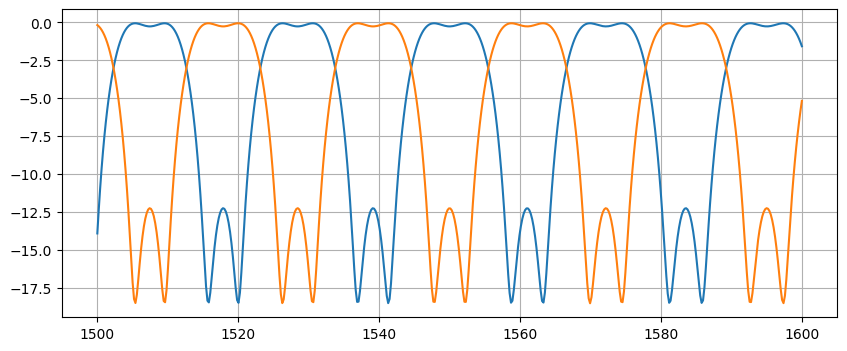

In [10]:
plt.figure(figsize=(10,4))
plt.plot(wl*1e9, bar_port_db, label="Bar Port (dB)")
plt.plot(wl*1e9, cross_port_db, label="Cross Port (dB)")
plt.grid()

# Bloque 2

In [15]:
B_bar_up = []
B_cross_up = []

FSR = 50e-9 # 50 nm
# delta_L2 = lambda0**2 / (n_g * FSR)
delta_L2 = delta_L/2

for i, w in enumerate(wl):
    Ein2 = np.array([0, bar_port[i]])
    H2 = MZIc(w, delta_L2, n_eff, lambda0)
    Eout2 = H2 @ Ein2
    B_bar_up.append(Eout2[0])
    B_cross_up.append(Eout2[1])

B_bar_up_power = np.abs(B_bar_up)**2
B_cross_up_power = np.abs(B_cross_up)**2

B_bar_up_db = to_db(B_bar_up_power)
B_cross_up_db = to_db(B_cross_up_power)


In [16]:
B_bar_dw = []
B_cross_dw = []

for i, w in enumerate(wl):
    Ein2 = np.array([0, cross_port[i]])
    H2 = MZIc(w, delta_L2, n_eff, lambda0)
    Eout2 = H2 @ Ein2
    B_bar_dw.append(Eout2[0])
    B_cross_dw.append(Eout2[1])


B_bar_dw_power = np.abs(B_bar_dw)**2
B_cross_dw_power = np.abs(B_cross_dw)**2

B_bar_dw_db = to_db(B_bar_dw_power)
B_cross_dw_db = to_db(B_cross_dw_power)

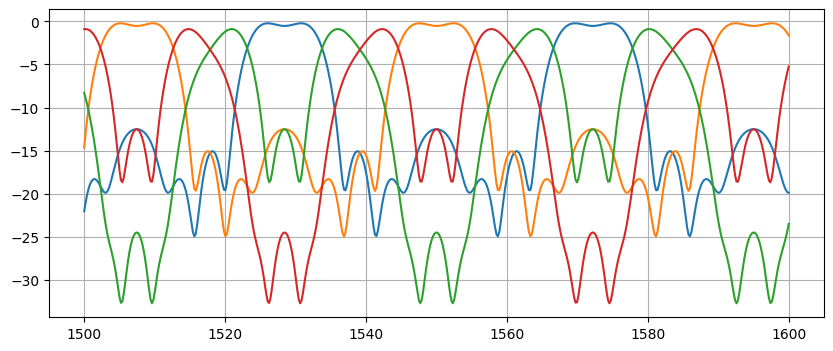

In [21]:
plt.figure(figsize=(10,4))
plt.plot(wl*1e9, B_bar_up_db, label="Bar Port (dB)")
plt.plot(wl*1e9, B_cross_up_db, label="Cross Port (dB)")
plt.plot(wl*1e9, B_bar_dw_db, label="Bar Port (dB)")
plt.plot(wl*1e9, B_cross_dw_db, label="Cross Port (dB)")
plt.grid()

## Bloque 3

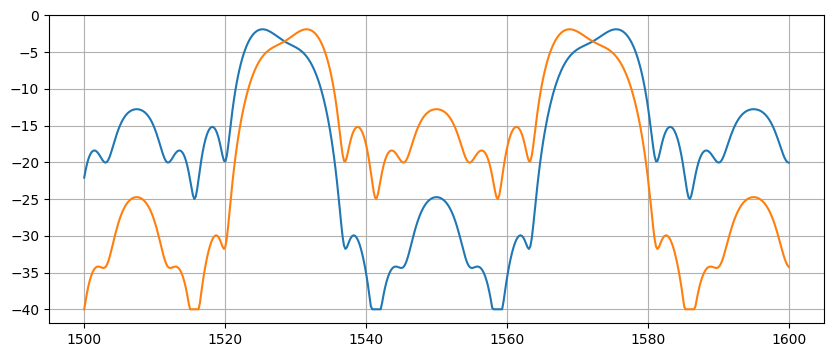

In [24]:
C_OUT_01 = []
C_OUT_02 = []

FSR = 50e-9 # 50 nm
# delta_L2 = lambda0**2 / (n_g * FSR)
delta_L3 = delta_L/4

for i, w in enumerate(wl):
    Ein2 = np.array([0, B_bar_up[i]])
    H2 = MZI(w, delta_L3, n_eff, lambda0)
    Eout2 = H2 @ Ein2
    C_OUT_01.append(Eout2[0])
    C_OUT_02.append(Eout2[1])

C_OUT_01_db = to_db(np.abs(C_OUT_01)**2)
C_OUT_02_db = to_db(np.abs(C_OUT_02)**2)


plt.figure(figsize=(10,4))
plt.plot(wl*1e9, C_OUT_01_db, label="Bar Port (dB)")
plt.plot(wl*1e9, C_OUT_02_db, label="Cross Port (dB)")
plt.grid()

---

In [114]:
# MMI (50/50 coupler)
def MMI():
    return (1/np.sqrt(2)) * np.array([[1, 1j],
                                      [1j, 1]])

# Phase shifter ahora depende de lambda
def phase_shifter(wl, delta_L, n_eff, lambda0):
    phi = 2 * np.pi * n_eff * delta_L * (1/wl - 1/lambda0)
    # phi = 2 * np.pi * n_eff * delta_L * (1/wl)
    return np.array([[np.exp(1j * phi), 0],
                     [0, 1]])

# MZI físico
def MZI(wl, delta_L, n_eff, lambda0):
    U = MMI()
    P = phase_shifter(wl, delta_L, n_eff, lambda0)
    return U @ P @ U

In [131]:
# Parámetros
n_eff = 2.4           # indice efectivo 2.4
n_g = 4.2             # índice de grupo 4.2
lambda0 = 1550e-9     # longitud de onda central
FSR = 100e-9          # 100 nm

delta_L = lambda0**2 / (n_g * FSR)

wl = np.linspace(1400e-9, 1700e-9, 500)

# Es necesario excitar una de las entradas para dejar de manejar matrices
# 2x2 y tener una relacion entrada salida del sistema
Ein = np.array([1, 0])

# Bloque A

Este solo se compone de un MZI

In [132]:
bar_port = [] # Al utilizar el metodo append lo que se generara es una lista
cross_port = []

for w in wl:
    H = MZI(w, delta_L, n_eff, lambda0)
    Eout = H @ Ein
    bar_port.append(Eout[0])
    cross_port.append(Eout[1])


p_bar_port = np.abs(bar_port)**2
p_cross_port = np.abs(cross_port)**2


# Convert to dB (avoid -inf by setting minimum value)
def to_db(power, floor=1e-4):
    # Compara elemento a elemento y devuelve el de mayor valor
    power = np.maximum(power, floor)
    return 10 * np.log10(power)

bar_port_db = to_db(p_bar_port)
cross_port_db = to_db(p_cross_port)


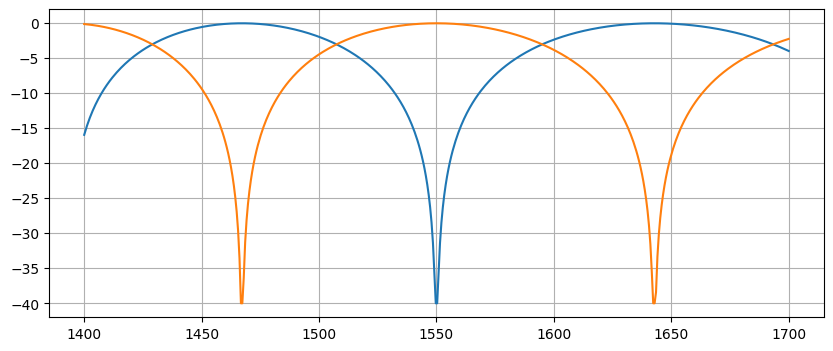

In [133]:
plt.figure(figsize=(10,4))
plt.plot(wl*1e9, bar_port_db, label="Bar Port (dB)")
plt.plot(wl*1e9, cross_port_db, label="Cross Port (dB)")
plt.grid()

# Bloque B

Este se compone de dos MZI

In [134]:
B_bar_up = []
B_cross_up = []

FSR = 50e-9 # 50 nm
# delta_L2 = lambda0**2 / (n_g * FSR)
delta_L2 = delta_L/2

for i, w in enumerate(wl):
    Ein2 = np.array([0, bar_port[i]])
    H2 = MZI(w, delta_L2, n_eff, lambda0)
    Eout2 = H2 @ Ein2
    B_bar_up.append(Eout2[0])
    B_cross_up.append(Eout2[1])

B_bar_up_power = np.abs(B_bar_up)**2
B_cross_up_power = np.abs(B_cross_up)**2

B_bar_up_db = to_db(B_bar_up_power)
B_cross_up_db = to_db(B_cross_up_power)


# ------------------------------------------------------

B_bar_dw = []
B_cross_dw = []

for i, w in enumerate(wl):
    Ein2 = np.array([0, cross_port[i]])
    H2 = MZI(w, delta_L2, n_eff, lambda0)
    Eout2 = H2 @ Ein2
    B_bar_dw.append(Eout2[0])
    B_cross_dw.append(Eout2[1])


B_bar_dw_power = np.abs(B_bar_dw)**2
B_cross_dw_power = np.abs(B_cross_dw)**2

B_bar_dw_db = to_db(B_bar_dw_power)
B_cross_dw_db = to_db(B_cross_dw_power)

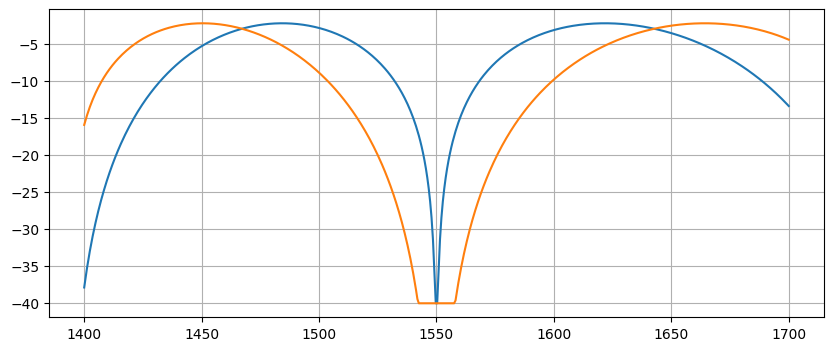

In [135]:
plt.figure(figsize=(10,4))
plt.plot(wl*1e9, B_bar_up_db, label="Bar Port (dB)")
plt.plot(wl*1e9, B_cross_up_db, label="Cross Port (dB)")
plt.grid()

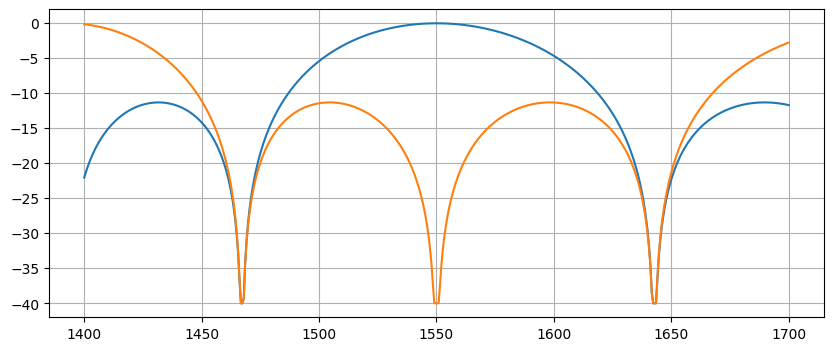

In [136]:
plt.figure(figsize=(10,4))
plt.plot(wl*1e9, B_bar_dw_db, label="Bar Port (dB)")
plt.plot(wl*1e9, B_cross_dw_db, label="Cross Port (dB)")
plt.grid()

# Bloque C

Este se compone de 4 MZI

In [137]:
C_OUT_01 = []
C_OUT_02 = []

FSR = 50e-9 # 50 nm
# delta_L2 = lambda0**2 / (n_g * FSR)
delta_L3 = delta_L/4

for i, w in enumerate(wl):
    Ein2 = np.array([0, B_bar_up[i]])
    H2 = MZI(w, delta_L3, n_eff, lambda0)
    Eout2 = H2 @ Ein2
    C_OUT_01.append(Eout2[0])
    C_OUT_02.append(Eout2[1])

C_OUT_01_db = to_db(np.abs(C_OUT_01)**2)
C_OUT_02_db = to_db(np.abs(C_OUT_02)**2)

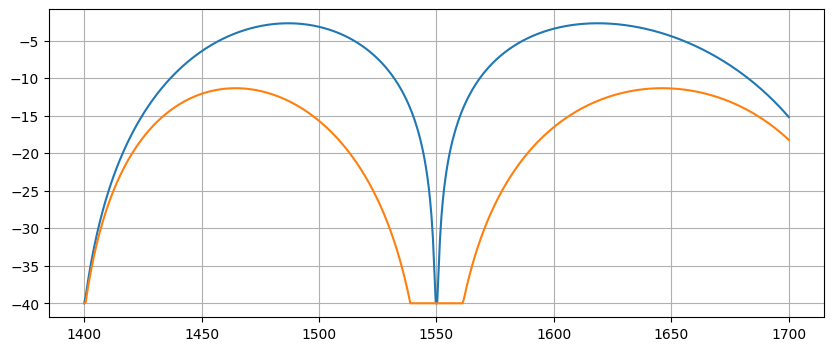

In [138]:
plt.figure(figsize=(10,4))
plt.plot(wl*1e9, C_OUT_01_db, label="Bar Port (dB)")
plt.plot(wl*1e9, C_OUT_02_db, label="Cross Port (dB)")
plt.grid()

In [139]:
C_OUT_03 = []
C_OUT_04 = []

FSR = 50e-9 # 50 nm
# delta_L2 = lambda0**2 / (n_g * FSR)
delta_L3 = delta_L/4

for i, w in enumerate(wl):
    Ein2 = np.array([0, B_cross_up[i]])
    H2 = MZI(w, delta_L3, n_eff, lambda0)
    Eout2 = H2 @ Ein2
    C_OUT_03.append(Eout2[0])
    C_OUT_04.append(Eout2[1])

C_OUT_03_db = to_db(np.abs(C_OUT_03)**2)
C_OUT_04_db = to_db(np.abs(C_OUT_04)**2)

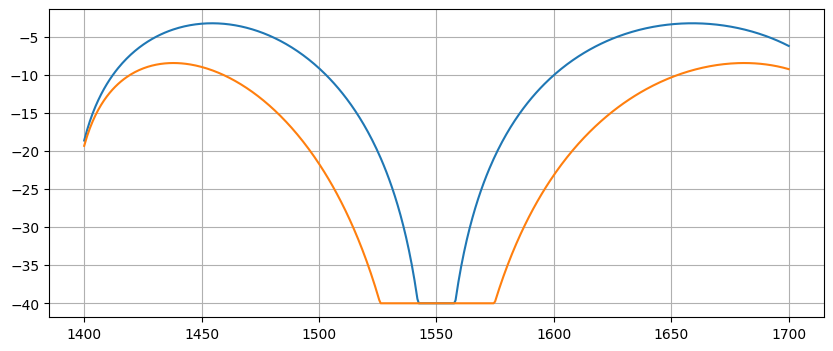

In [140]:
plt.figure(figsize=(10,4))
plt.plot(wl*1e9, C_OUT_03_db, label="Bar Port (dB)")
plt.plot(wl*1e9, C_OUT_04_db, label="Cross Port (dB)")
plt.grid()

In [141]:
C_OUT_05 = []
C_OUT_06 = []

FSR = 50e-9 # 50 nm
# delta_L2 = lambda0**2 / (n_g * FSR)
delta_L3 = delta_L/4

for i, w in enumerate(wl):
    Ein2 = np.array([0, B_bar_dw[i]])
    H2 = MZI(w, delta_L3, n_eff, lambda0)
    Eout2 = H2 @ Ein2
    C_OUT_05.append(Eout2[0])
    C_OUT_06.append(Eout2[1])

C_OUT_05_db = to_db(np.abs(C_OUT_05)**2)
C_OUT_06_db = to_db(np.abs(C_OUT_06)**2)

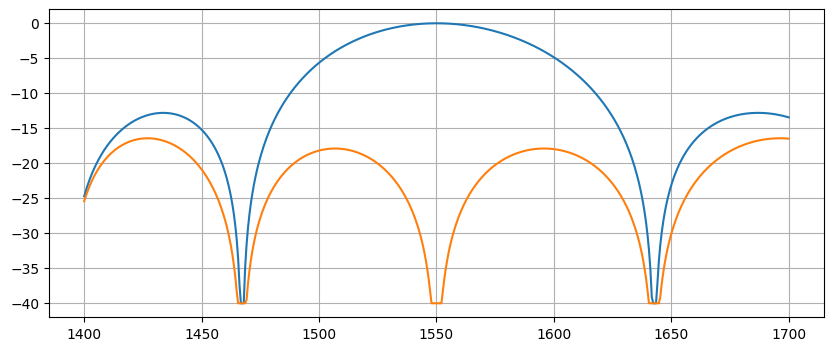

In [142]:
plt.figure(figsize=(10,4))
plt.plot(wl*1e9, C_OUT_05_db, label="Bar Port (dB)")
plt.plot(wl*1e9, C_OUT_06_db, label="Cross Port (dB)")
plt.grid()

In [143]:
C_OUT_07 = []
C_OUT_08 = []

FSR = 50e-9 # 50 nm
# delta_L2 = lambda0**2 / (n_g * FSR)
delta_L3 = delta_L/4

for i, w in enumerate(wl):
    Ein2 = np.array([0, B_cross_dw[i]])
    H2 = MZI(w, delta_L3, n_eff, lambda0)
    Eout2 = H2 @ Ein2
    C_OUT_07.append(Eout2[0])
    C_OUT_08.append(Eout2[1])

C_OUT_07_db = to_db(np.abs(C_OUT_07)**2)
C_OUT_08_db = to_db(np.abs(C_OUT_08)**2)

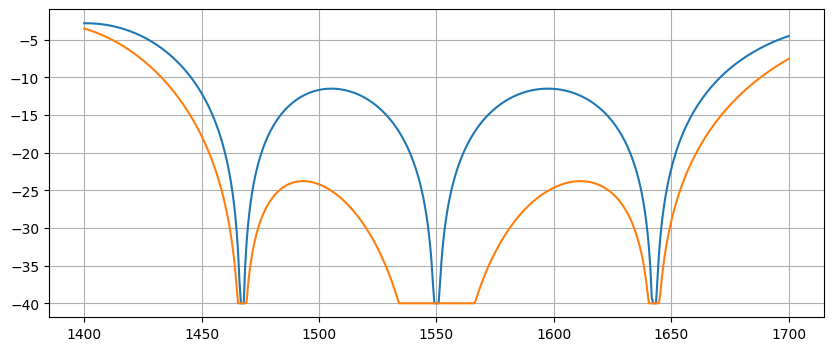

In [144]:
plt.figure(figsize=(10,4))
plt.plot(wl*1e9, C_OUT_07_db, label="Bar Port (dB)")
plt.plot(wl*1e9, C_OUT_08_db, label="Cross Port (dB)")
plt.grid()